<a href="https://colab.research.google.com/github/Krishnaveni186-Git/FSDS-Adv-GenAI-and-Adv-Agentic-AI/blob/main/Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-08-26 13:59:24--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 13.200.41.136, 13.200.41.134, 13.200.41.135, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.136|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-26 13:59:24 ERROR 404: Not Found.



In [14]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [16]:
img_height, img_width = 33,32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/train',
    image_size = (img_height, img_width),
    batch_size = batch_size
    )

test_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/test',
    image_size = (img_height, img_width),
    batch_size = batch_size
    )
val_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/validation',
    image_size = (img_height, img_width),
    batch_size = batch_size
    )

Found 460 files belonging to 3 classes.
Found 130 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


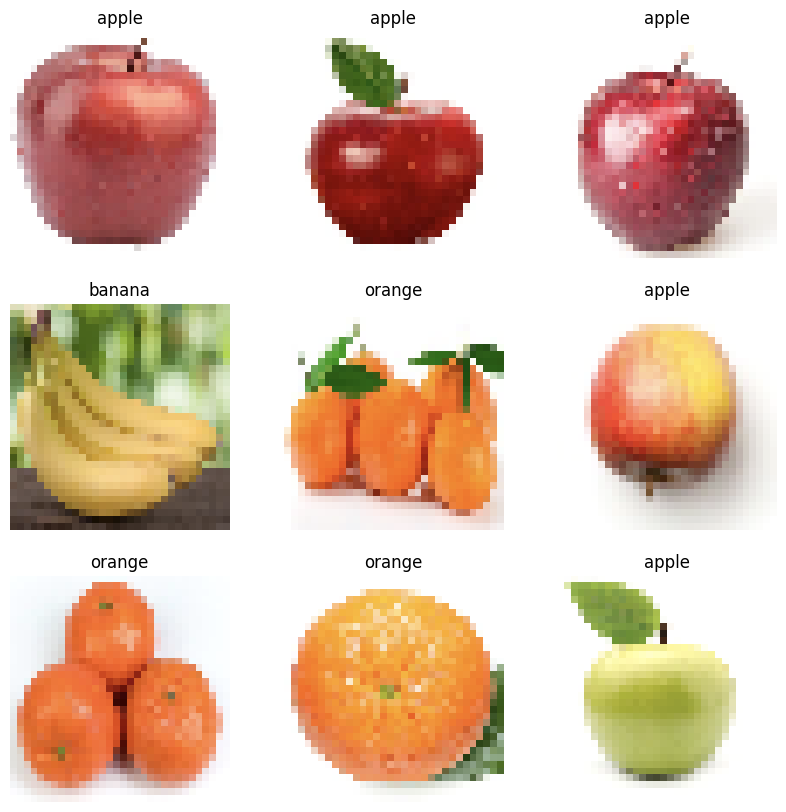

In [22]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize = (10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='softmax'),
    tf.keras.layers.Dense(3)
])

In [25]:
model.compile(
    optimizer = "rmsprop",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

In [26]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 25
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.3522 - loss: 1.0983 - val_accuracy: 0.3485 - val_loss: 1.0970
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3826 - loss: 1.0925 - val_accuracy: 0.3333 - val_loss: 1.0748
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.4674 - loss: 1.0544 - val_accuracy: 0.5909 - val_loss: 0.9973
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.5826 - loss: 0.9920 - val_accuracy: 0.6364 - val_loss: 0.9602
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6500 - loss: 0.9674 - val_accuracy: 0.5909 - val_loss: 0.9549
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7174 - loss: 0.9476 - val_accuracy: 0.8182 - val_loss: 0.8941
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.7435 - loss: 0.9174 - val_accuracy: 0.8333 - val_loss: 0.8789
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7674 - loss: 0.8945 - val_accuracy: 0.6667

In [28]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.9385 - loss: 0.5349


[0.5349445343017578, 0.9384615421295166]

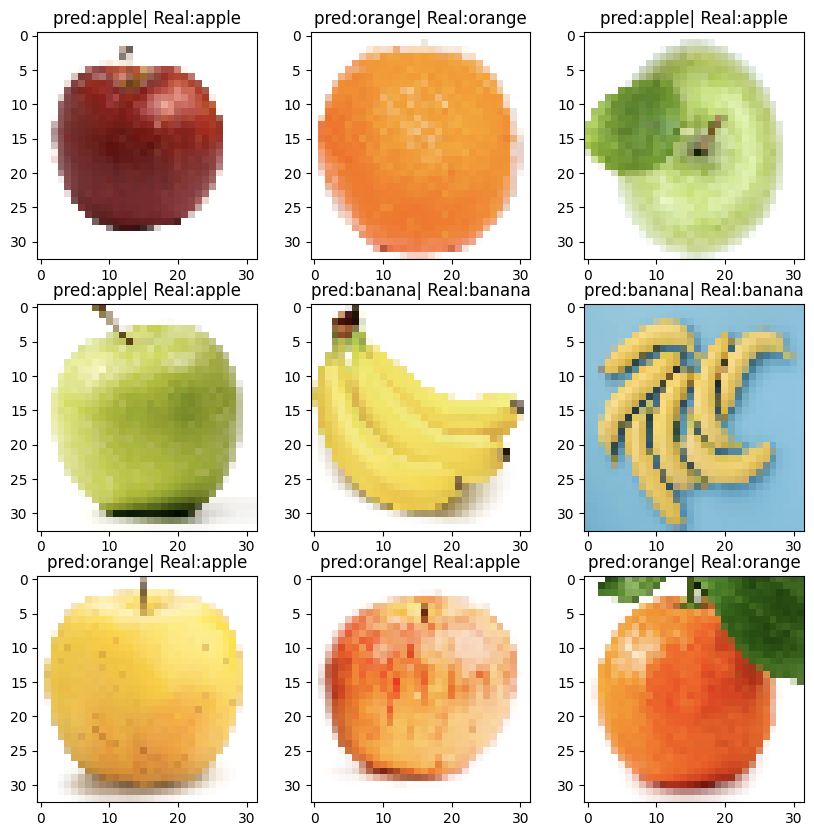

In [29]:
from prompt_toolkit.styles.style import CLASS_NAMES_RE
import numpy

plt.figure(figsize = (10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  for i in range(9):
    ax = plt.subplot(3,3,i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("pred:" + class_names[index] + "| Real:" + class_names[labels[i]])

In [30]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpzix14aph'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 33, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138534009515728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009514192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009505744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009505552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009514384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009505360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534007859984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534007648912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534007648720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138534009516496: TensorSpec(shape=(), dtype=tf.resource, name=None)
